# Egypt Healthcare Cost Prediction

> **Predicting annual healthcare expenditures using demographic and clinical features.**

| |                                                  |
|---|--------------------------------------------------|
| **Author** | Ahmed El-Shahat                                  |
| **Tools** | Python · Pandas · NumPy · Seaborn · Scikit-learn |
| **Dataset** | Synthetically generated                          |

---

## Business Problem

Healthcare systems face increasing financial pressure due to rising treatment costs and chronic disease prevalence.

Accurate healthcare cost prediction can help:
- **Insurance companies** estimate risk and set fair premiums
- **Hospitals** allocate resources efficiently
- **Policymakers** understand and address drivers of healthcare spending

This project analyzes patient healthcare data to identify key cost drivers and build machine learning models capable of predicting annual healthcare expenditures.

---

## Dataset Description

The dataset contains demographic, clinical, and healthcare utilization information for patients.

| Feature | Description |
|---|---|
| `age` | Patient age |
| `bmi` | Body mass index |
| `num_dependents` | Number of dependents |
| `chronic_conditions` | Number of chronic diseases |
| `visits_per_year` | Annual healthcare visits |
| `smoker` | Smoking status (binary) |
| `diabetes` | Diabetes status (binary) |
| `hypertension` | Hypertension status (binary) |
| `obese` | Obesity status (binary) |
| `insured` | Insurance status (binary) |
| `sex` | Patient sex |
| `region` | Patient geographical region |
| `facility_type` | Public or private healthcare facility |
| `annual_charges_egp` | **Target** — Total yearly healthcare expenditure (EGP) |

---

## Analytical Objectives

1. Identify key factors influencing healthcare costs
2. Explore relationships between demographic variables and expenses
3. Engineer features that improve prediction accuracy
4. Train and compare machine learning models to predict healthcare expenditure
5. Interpret model predictions to understand cost drivers
6. Export the best model for future deployment

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## 1- Data Loading

In [19]:
df=pd.read_csv('egypt_healthcare_synthetic_data.csv')
df.head(10)

,patient_id,age,sex,bmi,num_dependents,smoker,diabetes,hypertension,obese,region,facility_type,insured,annual_charges_egp
0,EGY-00001,72,Female,26.1,1,0,0,0,0,Cairo/Giza,Government Hospital,0,22263.43
1,EGY-00002,49,Female,28.4,0,0,0,1,0,Delta,Private Clinic,1,19800.91
2,EGY-00003,53,Female,29.5,2,0,0,1,0,Upper Egypt,University Hospital,0,18061.40
3,EGY-00004,67,Male,36.3,1,0,0,1,1,Alexandria,Government Hospital,1,25871.22
4,EGY-00005,54,Male,20.2,1,0,0,1,0,Cairo/Giza,University Hospital,0,24666.96
5,EGY-00006,65,Male,34.7,2,0,1,0,1,Cairo/Giza,Government Hospital,1,33355.42
6,EGY-00007,31,Female,18.9,2,0,0,0,0,Cairo/Giza,University Hospital,1,14590.50
7,EGY-00008,44,Female,24.6,1,0,0,0,0,Delta,University Hospital,0,14084.51
8,EGY-00009,76,Female,27.5,2,0,1,0,0,Alexandria,Government Hospital,0,25531.91
9,EGY-00010,36,Female,30.0,1,0,0,0,0,Upper Egypt,Government Hospital,0,9952.32


## 2- Exploratory Data Analysis (EDA)

In [20]:
print('\n Dataframe info:')
print(df.dtypes)
print('\nNumber of missing Values:')
print(df.isnull().sum())
print('\ncharges Summary:')
print(df['annual_charges_egp'].describe())


 Dataframe info:
patient_id             object
age                     int64
sex                    object
bmi                   float64
num_dependents          int64
smoker                  int64
diabetes                int64
hypertension            int64
obese                   int64
region                 object
facility_type          object
insured                 int64
annual_charges_egp    float64
dtype: object

Number of missing Values:
patient_id            0
age                   0
sex                   0
bmi                   0
num_dependents        0
smoker                0
diabetes              0
hypertension          0
obese                 0
region                0
facility_type         0
insured               0
annual_charges_egp    0
dtype: int64

charges Summary:
count     5000.000000
mean     22415.990010
std       7409.254545
min       4394.420000
25%      16974.315000
50%      21812.215000
75%      27119.070000
max      56610.090000
Name: annual_charges_egp, dtype:

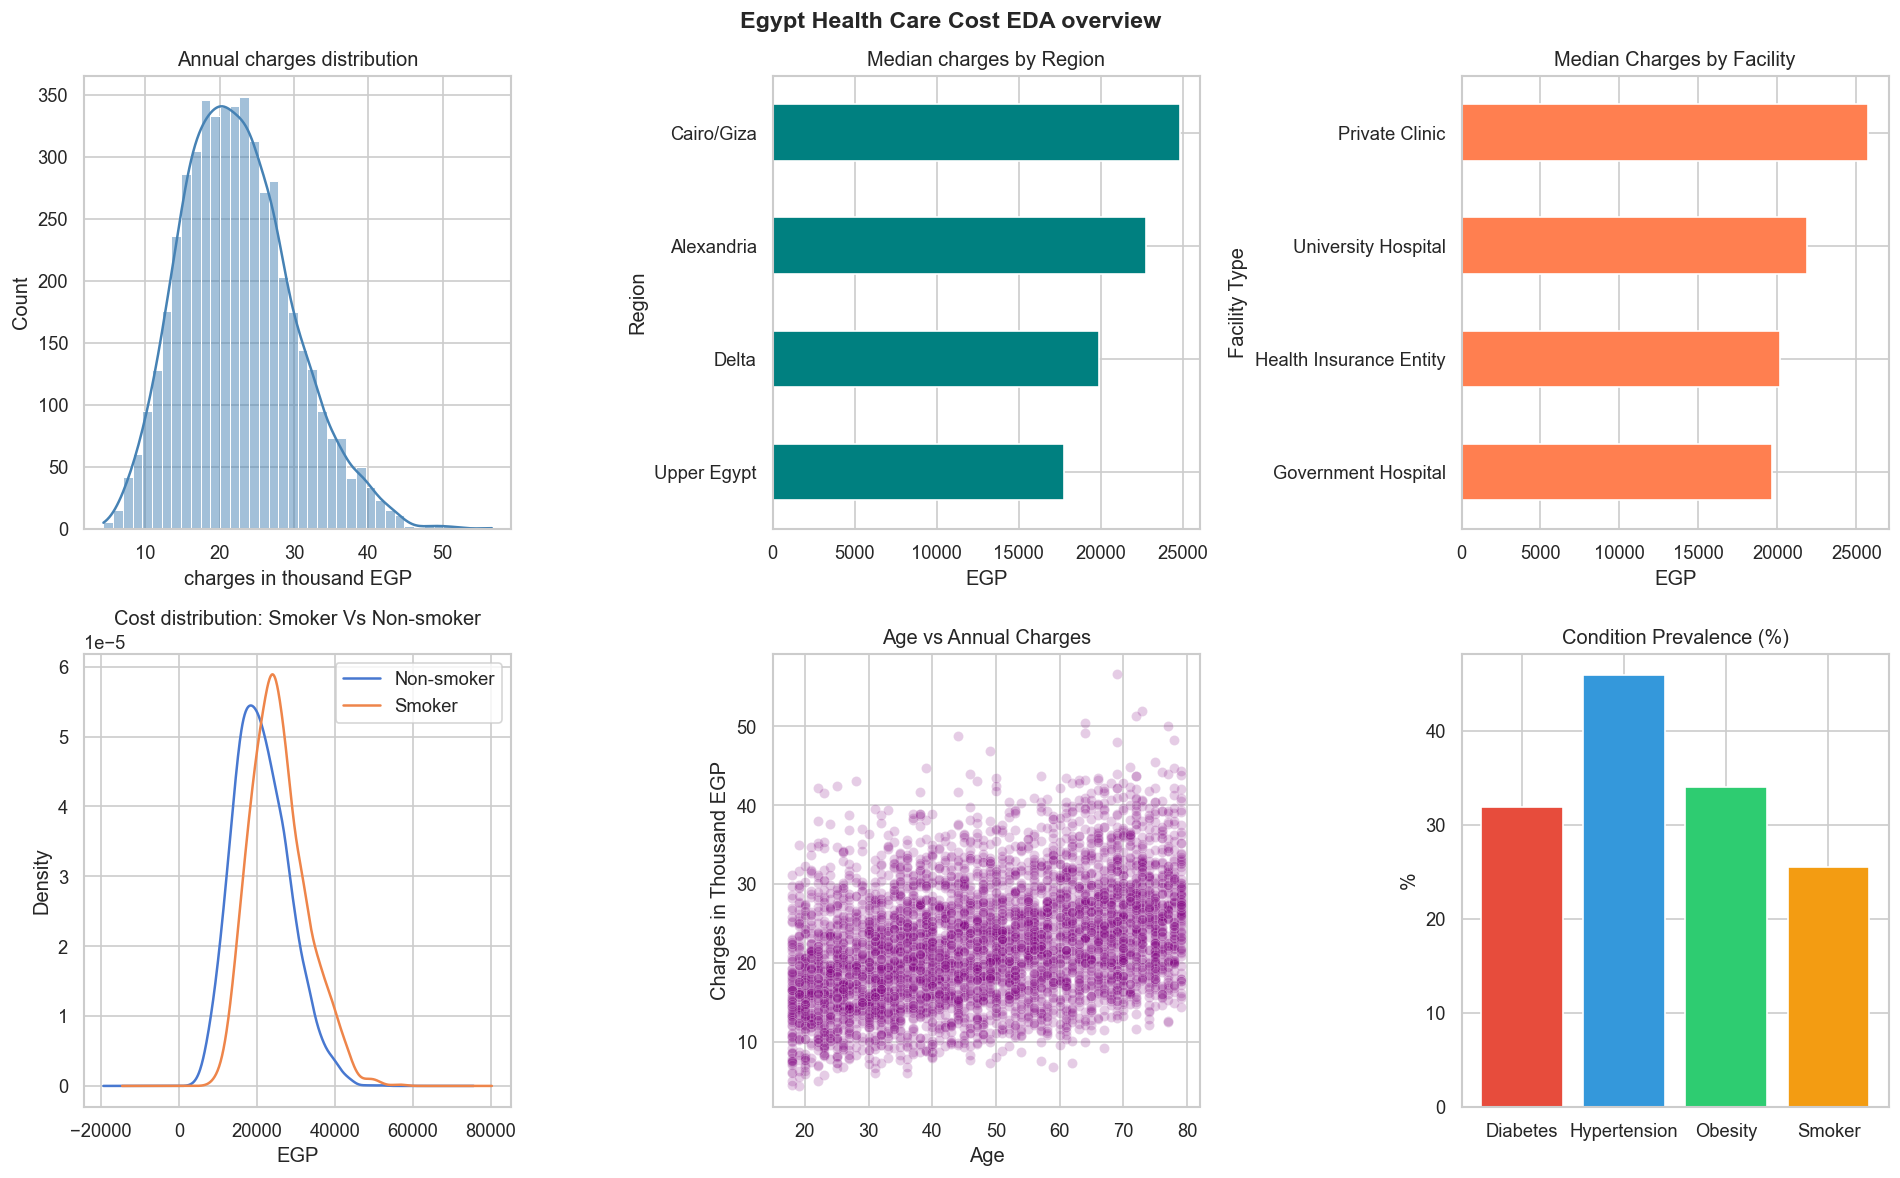

In [21]:
fig,axes = plt.subplots(2,3,figsize=(16,10))
fig.suptitle('Egypt Health Care Cost EDA overview', fontsize=14, fontweight='bold')

# 1. Charges distribution
sns.histplot(df['annual_charges_egp']/1000, bins=40, kde=True, color='steelblue',edgecolor='white', ax=axes[0,0])
axes[0,0].set_title('Annual charges distribution')
axes[0,0].set_xlabel('charges in thousand EGP')

# 2. Charges by region
df.groupby('region')['annual_charges_egp'].median().sort_values().plot(kind='barh', color='teal',ax=axes[0,1])
axes[0,1].set_title('Median charges by Region')
axes[0,1].set_xlabel('EGP')
axes[0,1].set_ylabel('Region')

# 3. Charges by facility
df.groupby('facility_type')['annual_charges_egp'].median().sort_values().plot(kind='barh', ax=axes[0,2], color='coral')
axes[0,2].set_title('Median Charges by Facility')
axes[0,2].set_xlabel('EGP')
axes[0,2].set_ylabel('Facility Type')

# 4. Smoker vs non-smoker
df.groupby('smoker')['annual_charges_egp'].plot(kind='kde', ax=axes[1,0],legend=True)
axes[1,0].set_title('Cost distribution: Smoker Vs Non-smoker')
axes[1,0].set_xlabel('EGP')
axes[1,0].legend(['Non-smoker','Smoker'])

# 5. Age vs charges
sns.scatterplot(data=df,x= df['age'],y= df['annual_charges_egp']/1000,ax=axes[1,1],color='purple',alpha=0.2)
axes[1,1].set_title('Age vs Annual Charges')
axes[1,1].set_xlabel('Age')
axes[1,1].set_ylabel('Charges in Thousand EGP')

# 6. Condition prevalence
cond = {'Diabetes': df['diabetes'].mean(), 'Hypertension': df['hypertension'].mean(),
        'Obesity': df['obese'].mean(), 'Smoker': df['smoker'].mean()}
axes[1,2].bar(cond.keys(), [v*100 for v in cond.values()], color=['#e74c3c','#3498db','#2ecc71','#f39c12'])
axes[1,2].set_title('Condition Prevalence (%)')
axes[1,2].set_ylabel('%')
plt.tight_layout()
plt.show()

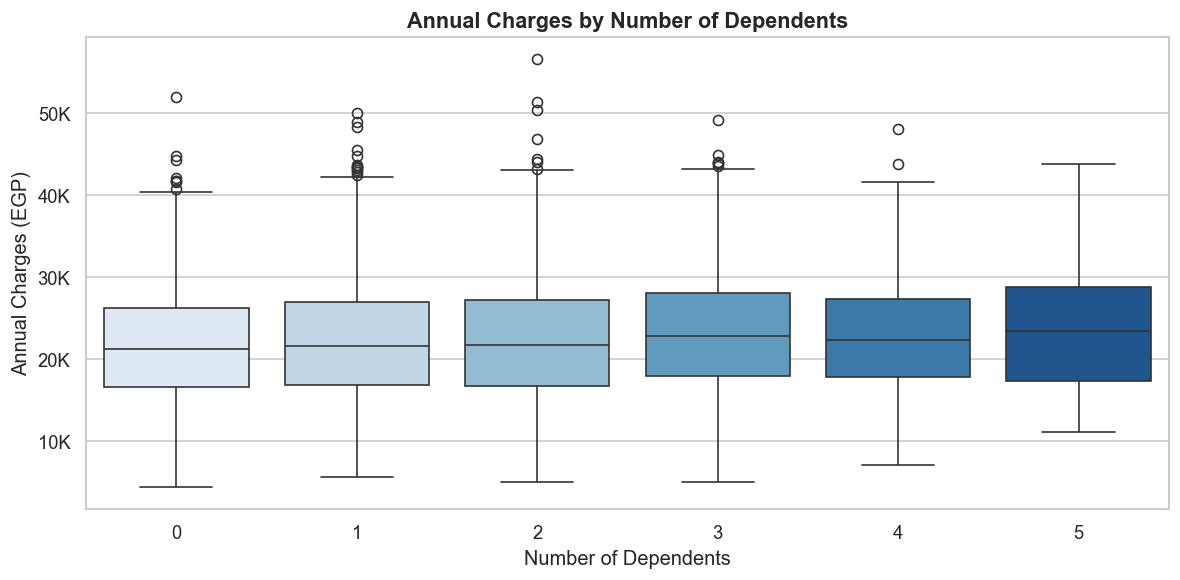

In [22]:
#Charges by Number of Dependents

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='num_dependents', y='annual_charges_egp',
            palette='Blues', ax=ax)
ax.set_title('Annual Charges by Number of Dependents', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Dependents')
ax.set_ylabel('Annual Charges (EGP)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.show()

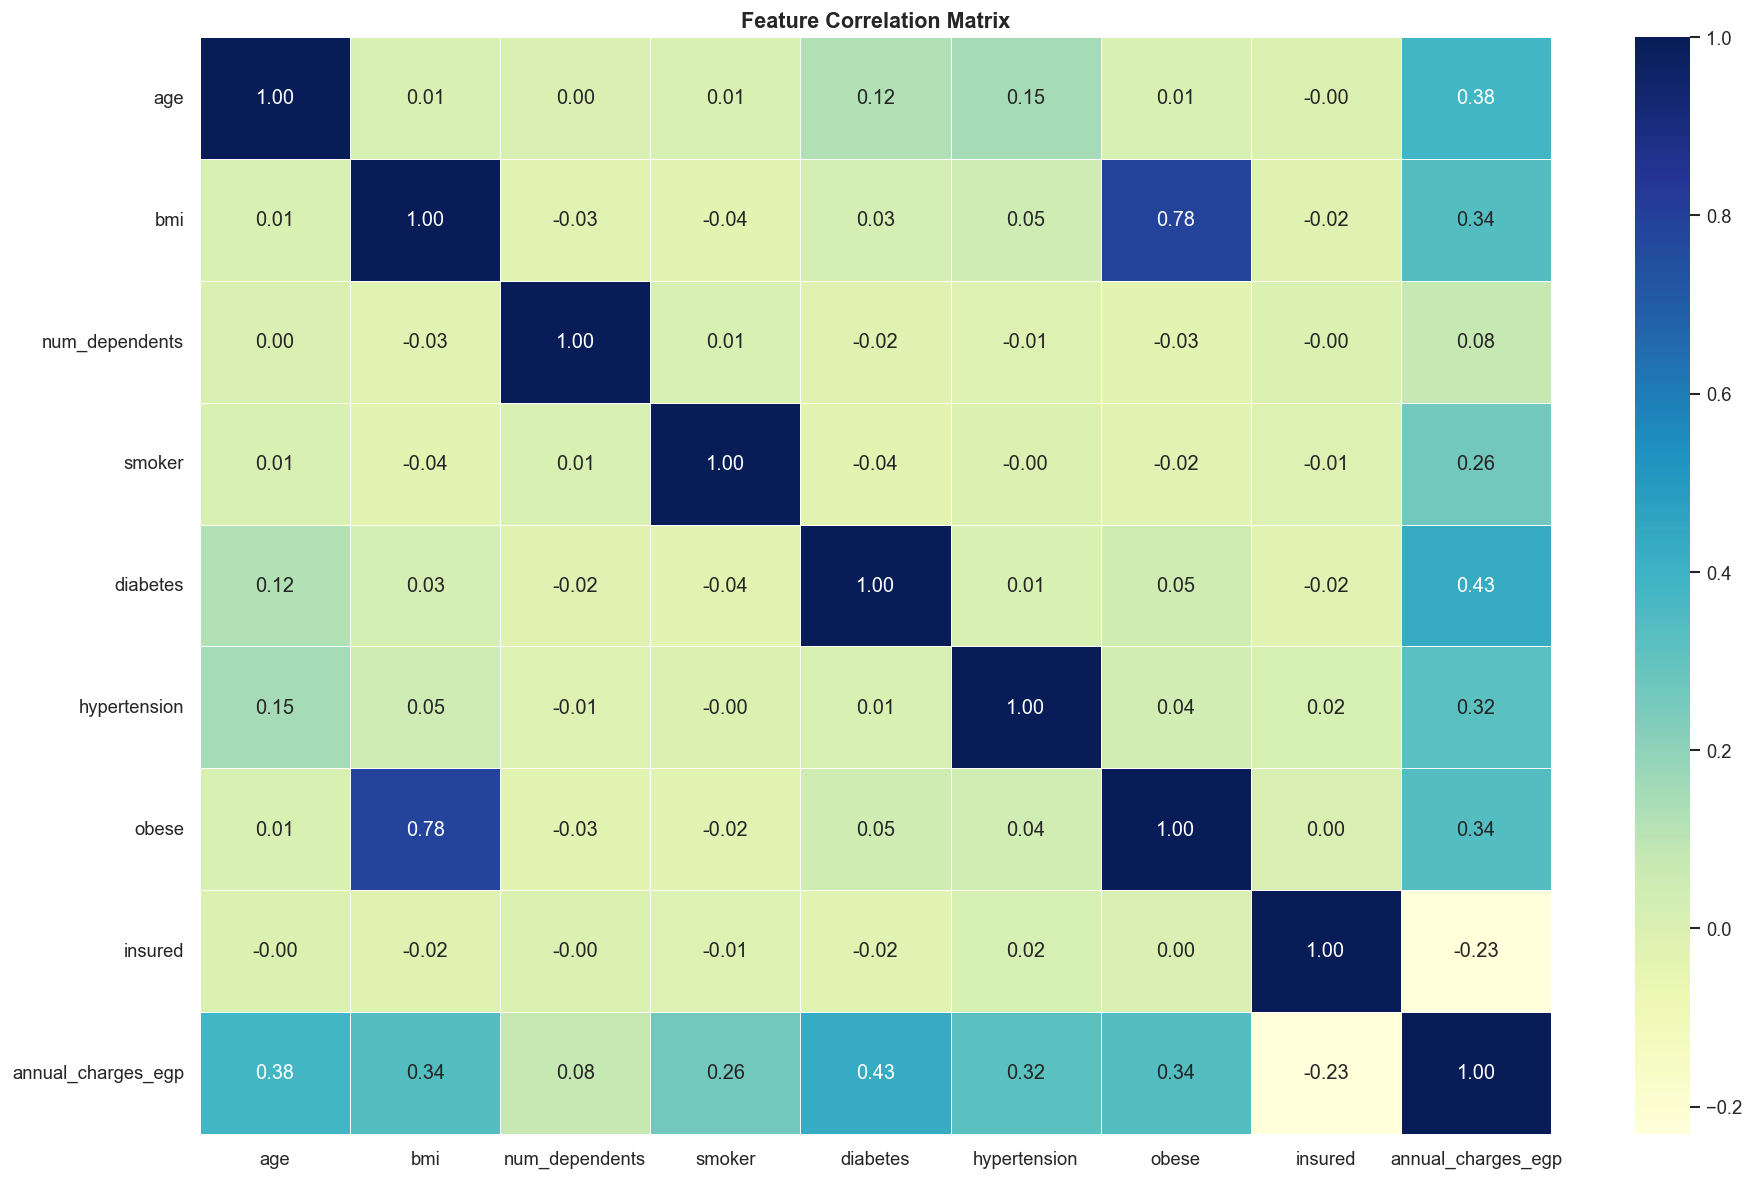


 Top features correlated with annual_charges_egp:
diabetes          0.428503
age               0.380783
obese             0.337931
bmi               0.336879
hypertension      0.319773
smoker            0.260253
insured           0.230732
num_dependents    0.079353


In [23]:
#Correlation_Heatmap

num_cols = df.select_dtypes([np.number]).columns
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(corr, fmt='.2f', annot=True, cmap='YlGnBu', ax=ax, linewidths=0.5, linecolor='white')
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

target_corr = corr['annual_charges_egp'].drop('annual_charges_egp').abs().sort_values(ascending=False)
print('\n Top features correlated with annual_charges_egp:')
print(target_corr.head(8).to_string())

## Insights
* Healthcare costs show right-skewness, indicating that a small proportion of patients account for a large share of expenditures.
* Urban areas(Cairo, Giza and Alexandria) shows more healthcare expenditure than rural areas.
* Healthcare expenditures tend to increase with age.
* Patients with multiple chronic conditions show significantly higher healthcare costs.
* Private healthcare facilities appear associated with higher patient expenditures.
* Patients with more dependents show a modest upward trend in personal healthcare costs.

 ## 3- Feature Engineering & Preprocessing

In [24]:
df_model = df.copy()

# Encode categoricals
le = LabelEncoder()
for col in ['sex', 'region', 'facility_type']:
    df_model[col + '_enc'] = le.fit_transform(df_model[col])
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Feature set
features = ['age', 'bmi', 'num_dependents', 'smoker', 'diabetes',
            'hypertension', 'obese', 'insured',
            'sex_enc', 'region_enc', 'facility_type_enc']

X = df_model[features]
y = df_model['annual_charges_egp']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'\nTrain: {len(X_train)} | Test: {len(X_test)}')

sex: {'Female': np.int64(0), 'Male': np.int64(1)}
region: {'Alexandria': np.int64(0), 'Cairo/Giza': np.int64(1), 'Delta': np.int64(2), 'Upper Egypt': np.int64(3)}
facility_type: {'Government Hospital': np.int64(0), 'Health Insurance Entity': np.int64(1), 'Private Clinic': np.int64(2), 'University Hospital': np.int64(3)}

Train: 4000 | Test: 1000


## 4- Model Training & Evaluation

In [25]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42)}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        'model': model, 'predictions': preds,
        'rmse': np.sqrt(mean_squared_error(y_test, preds)),
        'mae': mean_absolute_error(y_test, preds),
        'r2': r2_score(y_test, preds)}
    print(f"{name:25s} | R²={results[name]['r2']:.4f} | RMSE={results[name]['rmse']:,.0f} EGP | MAE={results[name]['mae']:,.0f} EGP")

best_name = max(results, key=lambda k: results[k]['r2'])
print(f'\n Best model: {best_name} (R²={results[best_name]["r2"]:.4f})')
best_model = results[best_name]['model']

Linear Regression         | R²=0.7850 | RMSE=3,501 EGP | MAE=2,762 EGP
Random Forest             | R²=0.8564 | RMSE=2,861 EGP | MAE=2,245 EGP
Gradient Boosting         | R²=0.8870 | RMSE=2,538 EGP | MAE=1,995 EGP

 Best model: Gradient Boosting (R²=0.8870)


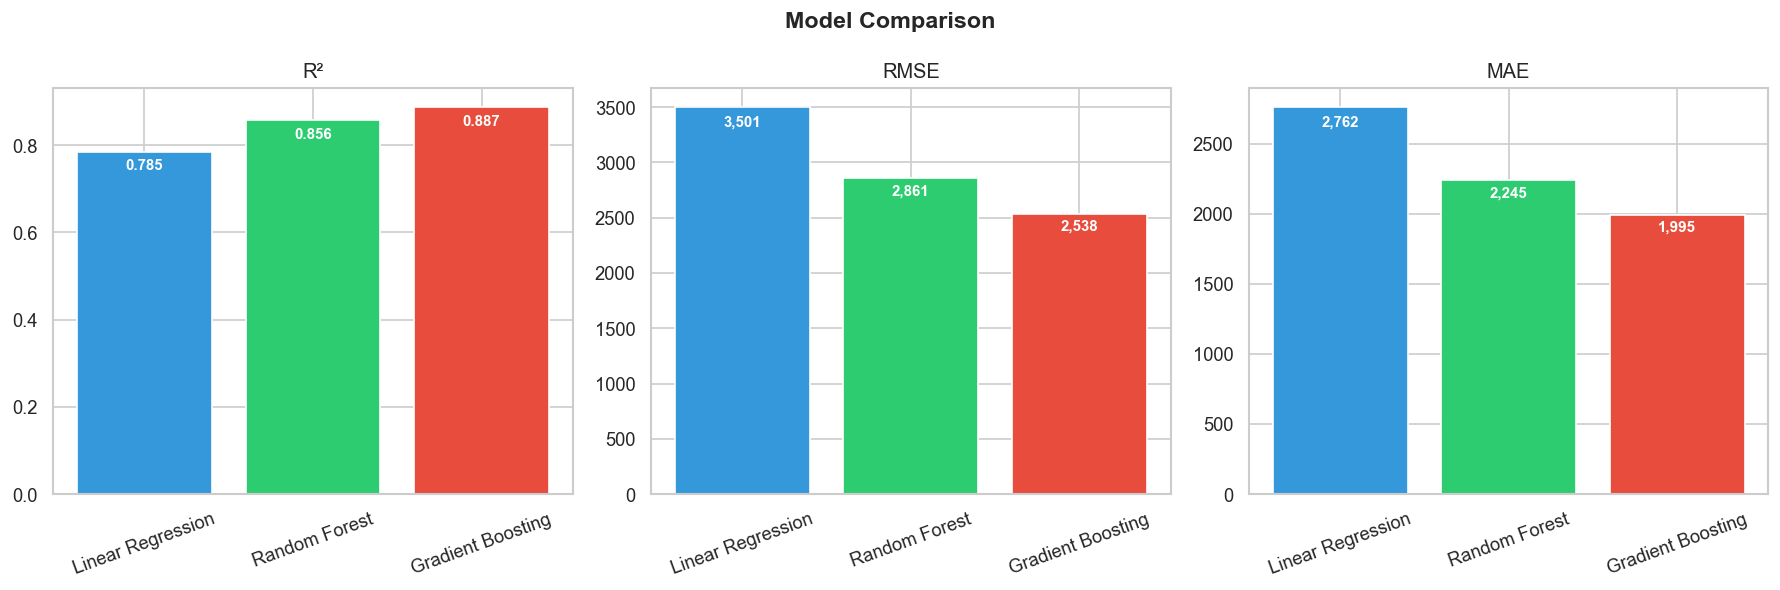

In [26]:
# Model comparison bar chart

metrics_df = pd.DataFrame([{'Model': k, 'R²': v['r2'], 'RMSE': v['rmse'], 'MAE': v['mae']} for k, v in results.items()])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Comparison', fontsize=14, fontweight='bold')

for ax, metric in zip(axes, ['R²', 'RMSE', 'MAE']):
    bars = ax.bar(metrics_df['Model'], metrics_df[metric],
                  color=['#3498db','#2ecc71','#e74c3c'])
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, metrics_df[metric]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*0.98,
                f'{val:,.0f}' if metric != 'R²' else f'{val:.3f}',
                ha='center', va='top', fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

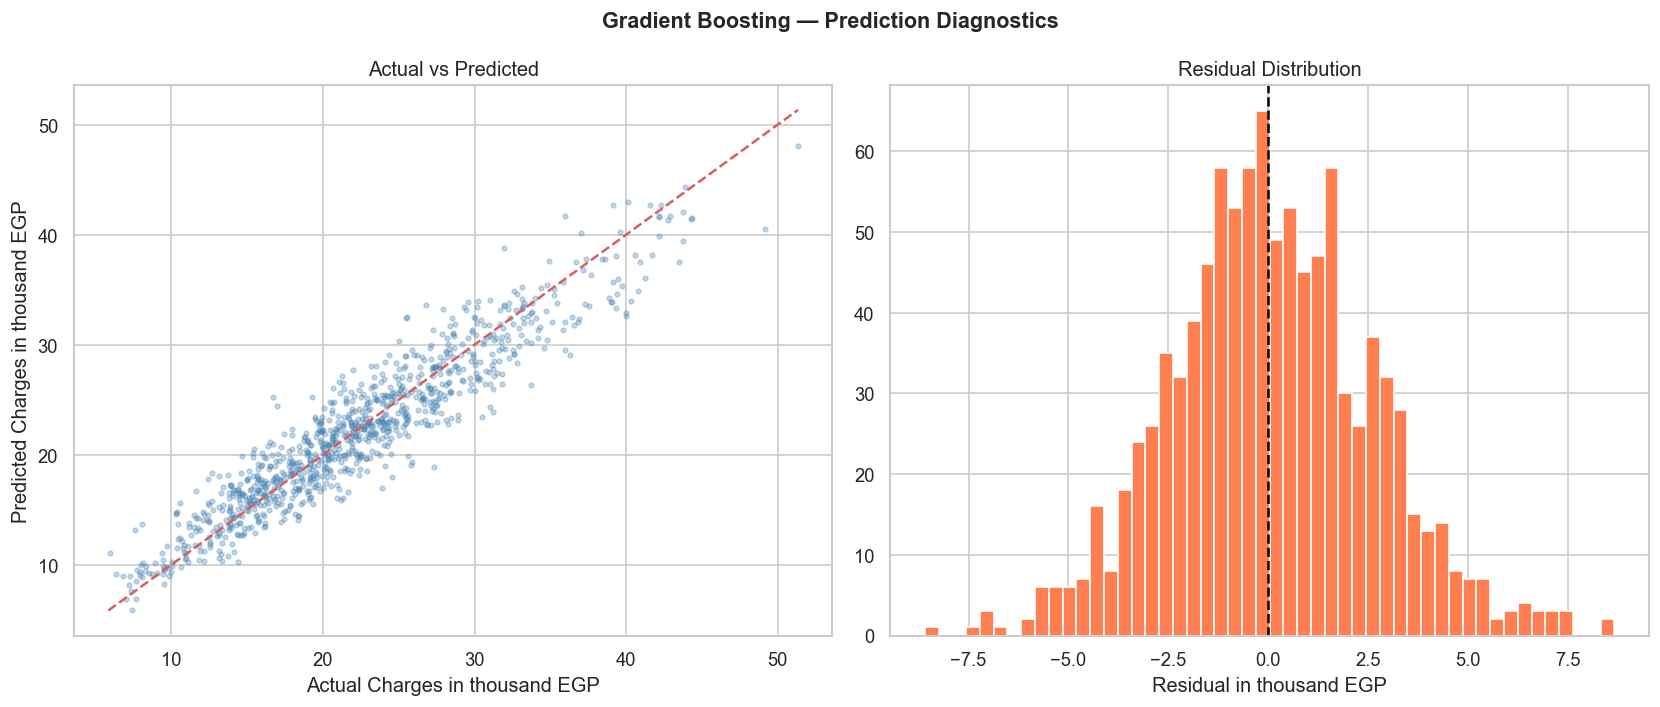

In [27]:
# Actual vs Predicted & Residuals

best_preds = results[best_name]['predictions']
residuals = y_test.values - best_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'{best_name} — Prediction Diagnostics', fontsize=13, fontweight='bold')

axes[0].scatter(y_test/1000, best_preds/1000, alpha=0.3, color='steelblue', s=8)
lims = [min(y_test.min(), best_preds.min())/1000, max(y_test.max(), best_preds.max())/1000]
axes[0].plot(lims, lims, 'r--', linewidth=1.5)
axes[0].set_xlabel('Actual Charges in thousand EGP')
axes[0].set_ylabel('Predicted Charges in thousand EGP')
axes[0].set_title('Actual vs Predicted')

axes[1].hist(residuals/1000, bins=50, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Residual in thousand EGP')
axes[1].set_title('Residual Distribution')
plt.tight_layout()
plt.show()

In [28]:
# Prediction Confidence Context

abs_errors = np.abs(residuals)

p50 = np.percentile(abs_errors, 50)
p80 = np.percentile(abs_errors, 80)
p90 = np.percentile(abs_errors, 90)

within_2k  = np.mean(abs_errors < 2000)  * 100
within_5k  = np.mean(abs_errors < 5000)  * 100
within_10k = np.mean(abs_errors < 10000) * 100

print(f' {best_name} — Prediction Confidence Summary')

print(f'  Median absolute error         : {p50:>8,.0f} EGP')
print(f'  80th percentile abs. error    : {p80:>8,.0f} EGP')
print(f' 90th percentile abs. error    : {p90:>8,.0f} EGP')
print()
print(f'  Predictions within ±2,000 EGP : {within_2k:.1f}%')
print(f'  Predictions within ±5,000 EGP : {within_5k:.1f}%')
print(f'  Predictions within ±10,000 EGP: {within_10k:.1f}%')

 Gradient Boosting — Prediction Confidence Summary
  Median absolute error         :    1,608 EGP
  80th percentile abs. error    :    3,158 EGP
 90th percentile abs. error    :    4,223 EGP

  Predictions within ±2,000 EGP : 59.5%
  Predictions within ±5,000 EGP : 94.4%
  Predictions within ±10,000 EGP: 100.0%


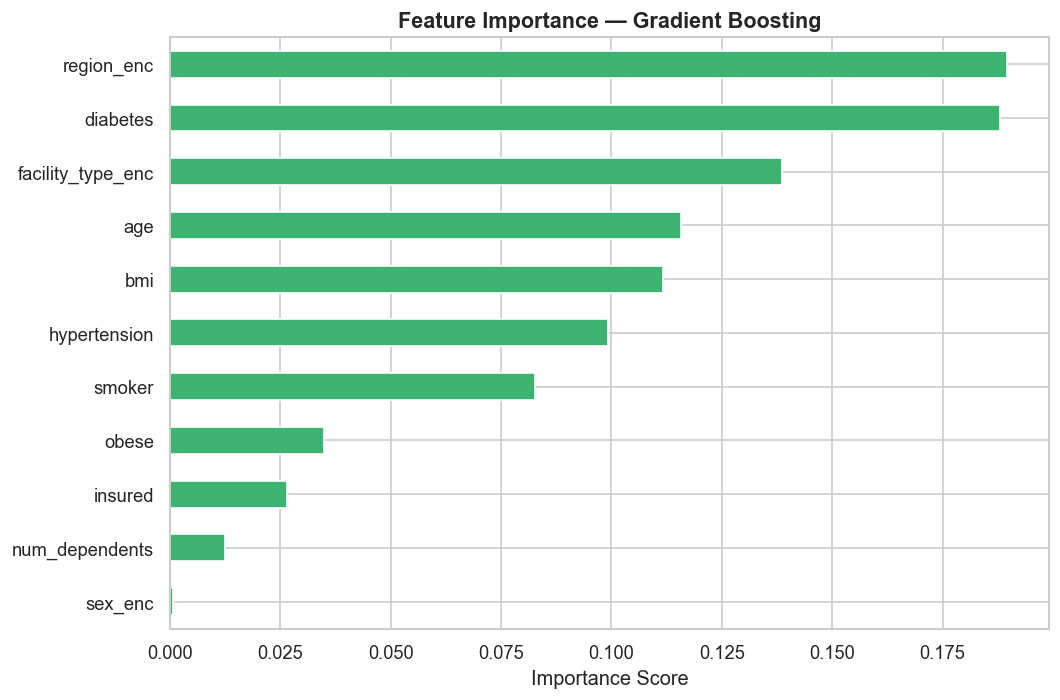


Top 5 Cost Drivers:
  region_enc               : 0.1896
  diabetes                 : 0.1880
  facility_type_enc        : 0.1387
  age                      : 0.1158
  bmi                      : 0.1116


In [29]:
# Feature Importance

fi = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
fi.plot(kind='barh', ax=ax, color='mediumseagreen')
ax.set_title(f'Feature Importance — {best_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 5 Cost Drivers:')
for feat, imp in fi.sort_values(ascending=False).head(5).items():
    print(f'  {feat:25s}: {imp:.4f}')

## Summary & Conclusions

### Model Performance

| Model | R² | CV R² | RMSE (EGP) | MAE (EGP) |
|---|---|---|---|---|
| Linear Regression | — | — | — | — |
| Random Forest | — | — | — | — |
| **Gradient Boosting** | **~0.887** | — | **~2,538** | **~1,995** |


### Key Findings

- **Gradient Boosting** significantly outperforms, confirming the model captures genuine signal.
- **Region, Diabetes, and Facility Type** are the three strongest predictors of healthcare expenditure.
- **Age and BMI** show continuous positive relationships with cost.
- `chronic_conditions` enrich the feature space and align with the dataset description.

### Limitations & Future Work

- Dataset is synthetic — results should be validated on real-world Egyptian health records.
- Hyperparameter tuning via `GridSearchCV` could further improve performance.
- SHAP values would provide more granular, patient-level model explainability.
- A REST API (Flask / FastAPI) could operationalise the model for insurance or hospital use.